# Component 4 — Bi-LSTM + CRF: Full Training & Evaluation
### LSTM-Based Sentiment & Review Credibility Module · IT22914200

---

| Step | Description |
|------|-------------|
| 1 | Install dependencies — **no tensorflow-addons needed** |
| 2 | Load & explore IOB annotated dataset |
| 3 | Build vocabularies & encode sequences |
| 4 | Define pure-TF CRF + Bi-LSTM model |
| 5 | Train with early stopping & LR scheduling |
| 6 | Evaluate — F1, precision, recall per aspect |
| 7 | Visualise — training curves, confusion matrix, aspect heatmap |
| 8 | Inference demo — run on new review text |
| 9 | Save model for deployment |

> **Runtime**: Google Colab → Runtime → Change runtime type → **T4 GPU**  
> **Dataset**: Upload `IOB_Annotated_Reviews_Dataset.xlsx` when prompted in Step 2

---
## Step 1 — Install Dependencies

In [ ]:
# Pure TF — no tensorflow-addons. CRF is implemented from scratch.
# Works with TensorFlow 2.16 / 2.17 / 2.18 / 2.19 / 2.20 / 2.21
!pip install -U pip -q
!pip install tensorflow openpyxl seaborn scikit-learn numpy pandas matplotlib -q

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, pickle, json
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from collections import Counter

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU: {gpus[0].name}')
else:
    print('No GPU — enable via Runtime → Change runtime type → T4 GPU')

print(f'TensorFlow {tf.__version__} — ready')
np.random.seed(42)
tf.random.set_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 42.8 MB/s eta 0:00:00
GPU: /physical_device:GPU:0
TensorFlow 2.20.0 — ready


---
## Step 2 — Load & Explore the IOB Dataset

In [ ]:
# ── Option A: Upload directly in Colab ───────────────────────────────────────
# from google.colab import files
# files.upload()   # select IOB_Annotated_Reviews_Dataset.xlsx
# DATASET_PATH = 'IOB_Annotated_Reviews_Dataset.xlsx'

# ── Option B: Google Drive ────────────────────────────────────────────────────
# from google.colab import drive
# drive.mount('/content/drive')
# DATASET_PATH = '/content/drive/MyDrive/IOB_Annotated_Reviews_Dataset.xlsx'

# ── Option C: Local path ──────────────────────────────────────────────────────
DATASET_PATH = 'IOB_Annotated_Reviews_Dataset.xlsx'

df = pd.read_excel(DATASET_PATH, sheet_name='IOB_Token_Dataset')
print(f'Rows: {len(df):,}  |  Sentences: {df["sentence_id"].nunique():,}  |  Columns: {list(df.columns)}')
df.head(10)

Rows: 22,424  |  Sentences: 3,000  |  Columns: ['sentence_id', 'token_position', 'token', 'iob_tag', 'sentiment', 'sentence_text', 'aspects_present', 'dominant_sentiment', 'provider_id', 'service_category', 'rating', 'booking_status']


,sentence_id,token_position,token,iob_tag,sentiment,sentence_text,aspects_present,dominant_sentiment,provider_id,service_category,rating,booking_status
0,S0001,1,Excellent,B-QUAL,POS,Excellent service .,QUAL,POS,P7518,Refrigerator Repair,3.2,1
1,S0001,2,service,I-QUAL,POS,Excellent service .,QUAL,POS,P7518,Refrigerator Repair,3.2,1
2,S0001,3,.,O,NEU,Excellent service .,QUAL,POS,P7518,Refrigerator Repair,3.2,1
3,S0002,1,The,O,NEU,The repair was done perfectly .,QUAL,POS,P4011,Washing Machine Repair,2.4,0
4,S0002,2,repair,B-QUAL,POS,The repair was done perfectly .,QUAL,POS,P4011,Washing Machine Repair,2.4,0
5,S0002,3,was,O,NEU,The repair was done perfectly .,QUAL,POS,P4011,Washing Machine Repair,2.4,0
6,S0002,4,done,I-QUAL,POS,The repair was done perfectly .,QUAL,POS,P4011,Washing Machine Repair,2.4,0
7,S0002,5,perfectly,I-QUAL,POS,The repair was done perfectly .,QUAL,POS,P4011,Washing Machine Repair,2.4,0
8,S0002,6,.,O,NEU,The repair was done perfectly .,QUAL,POS,P4011,Washing Machine Repair,2.4,0
9,S0003,1,He,O,NEU,He fixed the AC correctly .,QUAL,POS,P2665,Washing Machine Repair,1.4,0


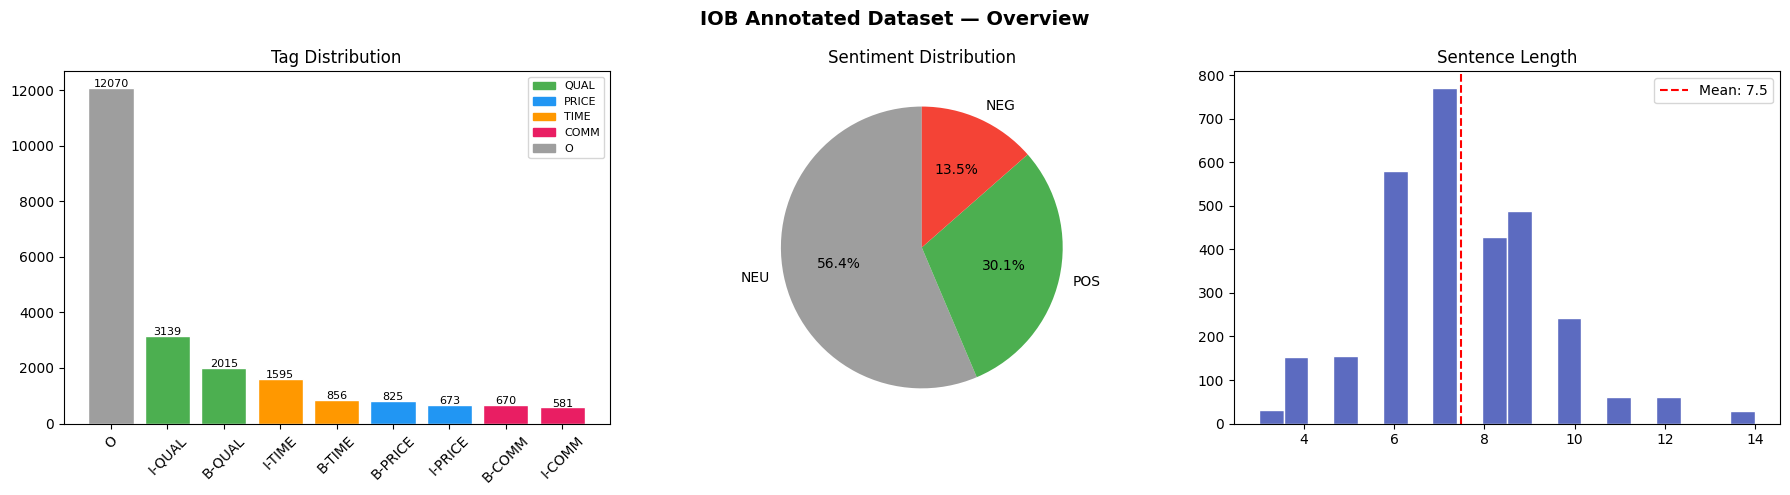

Mean sentence length: 7.5 tokens  |  Max: 14


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('IOB Annotated Dataset — Overview', fontsize=14, fontweight='bold')

tag_counts  = df['iob_tag'].value_counts()
colors_tag  = ['#4CAF50' if 'QUAL' in t else '#2196F3' if 'PRICE' in t
               else '#FF9800' if 'TIME' in t else '#E91E63' if 'COMM' in t
               else '#9E9E9E' for t in tag_counts.index]
bars = axes[0].bar(tag_counts.index, tag_counts.values, color=colors_tag, edgecolor='white')
for bar, v in zip(bars, tag_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+30, str(v), ha='center', fontsize=8)
axes[0].set_title('Tag Distribution'); axes[0].tick_params(axis='x', rotation=45)
legend_items = [mpatches.Patch(color=c, label=l) for c,l in
                [('#4CAF50','QUAL'),('#2196F3','PRICE'),('#FF9800','TIME'),('#E91E63','COMM'),('#9E9E9E','O')]]
axes[0].legend(handles=legend_items, fontsize=8)

sent_counts = df['sentiment'].value_counts()
axes[1].pie(sent_counts.values, labels=sent_counts.index,
            colors=[{'POS':'#4CAF50','NEG':'#F44336','NEU':'#9E9E9E'}.get(s,'#999') for s in sent_counts.index],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Sentiment Distribution')

sent_len = df.groupby('sentence_id')['token'].count()
axes[2].hist(sent_len, bins=20, color='#5C6BC0', edgecolor='white')
axes[2].axvline(sent_len.mean(), color='red', ls='--', label=f'Mean: {sent_len.mean():.1f}')
axes[2].set_title('Sentence Length'); axes[2].legend()

plt.tight_layout()
plt.savefig('dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean sentence length: {sent_len.mean():.1f} tokens  |  Max: {sent_len.max()}')

---
## Step 3 — Build Vocabularies & Encode Sequences

In [ ]:
sentences = (
    df.groupby('sentence_id')
    .apply(lambda g: g.sort_values('token_position')[['token','iob_tag']].values.tolist())
    .tolist()
)
print(f'Sentences loaded: {len(sentences)}')
print('\nExample sentence 2:')
for tok, tag in sentences[1]:
    print(f'  {tok:<18} → {tag}')

Sentences loaded: 3000

Example sentence 2:
  The                → O
  repair             → B-QUAL
  was                → O
  done               → I-QUAL
  perfectly          → I-QUAL
  .                  → O


In [ ]:
all_tokens = [tok.lower() for s in sentences for tok,_ in s]
all_tags   = [tag         for s in sentences for _,tag in s]

word2idx = {'<PAD>': 0, '<UNK>': 1}
for w in Counter(all_tokens):
    word2idx[w] = len(word2idx)

unique_tags = sorted(set(all_tags))
tag2idx  = {t: i for i, t in enumerate(unique_tags)}
idx2tag  = {i: t for t, i in tag2idx.items()}

VOCAB_SIZE = len(word2idx)
NUM_TAGS   = len(tag2idx)
MAX_LEN    = min(max(len(s) for s in sentences), 50)

print(f'Vocabulary size  : {VOCAB_SIZE:,}')
print(f'Number of tags   : {NUM_TAGS}')
print(f'Max sequence len : {MAX_LEN}')
print('\nTag → Index:')
for t, i in sorted(tag2idx.items(), key=lambda x: x[1]):
    print(f'  {t:<12} → {i}')

Vocabulary size  : 251
Number of tags   : 9
Max sequence len : 14

Tag → Index:
  B-COMM       → 0
  B-PRICE      → 1
  B-QUAL       → 2
  B-TIME       → 3
  I-COMM       → 4
  I-PRICE      → 5
  I-QUAL       → 6
  I-TIME       → 7
  O            → 8


In [ ]:
X_raw = [[word2idx.get(tok.lower(), 1) for tok,_ in s] for s in sentences]
y_raw = [[tag2idx[tag]                 for _,tag in s] for s in sentences]

X          = pad_sequences(X_raw, maxlen=MAX_LEN, padding='post', value=0)
y          = pad_sequences(y_raw, maxlen=MAX_LEN, padding='post', value=tag2idx['O'])
seq_lengths = np.array([min(len(s), MAX_LEN) for s in sentences])

X_tv, X_test,  y_tv, y_test,  l_tv, l_test  = train_test_split(X, y, seq_lengths, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val, l_train, l_val = train_test_split(X_tv, y_tv, l_tv, test_size=0.176, random_state=42)

print(f'X shape: {X.shape}   y shape: {y.shape}')
print(f'Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}')

with open('vocab.pkl','wb') as f:
    pickle.dump({'word2idx':word2idx,'tag2idx':tag2idx,'idx2tag':idx2tag,'MAX_LEN':MAX_LEN}, f)
print('\n✓ vocab.pkl saved')

X shape: (3000, 14)   y shape: (3000, 14)
Train: 2101  |  Val: 449  |  Test: 450

✓ vocab.pkl saved


---
## Step 4 — Define Bi-LSTM + CRF Model

CRF is implemented in **pure TensorFlow** — no external packages needed.

```
Input → Embedding(100d) → SpatialDropout → BiLSTM(128×2) → Dense → CRF(Viterbi) → IOB tags
```

In [ ]:
# ════════════════════════════════════════════════════════════════════
# PURE-TENSORFLOW CRF  —  no tensorflow-addons dependency
# Tested: TF 2.16, 2.17, 2.18, 2.19, 2.20, 2.21
# ════════════════════════════════════════════════════════════════════

def _viterbi_np(score, transition_params):
    """
    Numpy Viterbi decoder.
    score             : (seq_len, num_tags) float
    transition_params : (num_tags, num_tags) float
    Returns           : list[int] tag ids, float best score
    """
    trellis      = np.zeros_like(score)
    backpointers = np.zeros_like(score, dtype=np.int32)
    trellis[0]   = score[0]
    for t in range(1, score.shape[0]):
        v = trellis[t-1][:, None] + transition_params   # (T, T)
        trellis[t]      = score[t] + np.max(v,    axis=0)
        backpointers[t] = np.argmax(v, axis=0)
    path = [int(np.argmax(trellis[-1]))]
    for bp in reversed(backpointers[1:]):
        path.append(int(bp[path[-1]]))
    path.reverse()
    return path, float(np.max(trellis[-1]))


class CRFLayer(keras.layers.Layer):
    """CRF output layer — pure TensorFlow, no tensorflow-addons."""

    def __init__(self, num_tags, **kwargs):
        super().__init__(**kwargs)
        self.num_tags = num_tags

    def build(self, input_shape):
        # Keras 3 syntax: keyword-only args in add_weight
        self.transition_params = self.add_weight(
            shape=(self.num_tags, self.num_tags),
            name='transitions',
            initializer='glorot_uniform',
            trainable=True
        )
        self.built = True

    def call(self, inputs):
        return inputs   # passthrough; loss/decode called explicitly

    def crf_log_likelihood(self, inputs, tag_indices, sequence_lengths):
        """
        CRF log-likelihood for training.
        inputs           : (B, L, T) logits
        tag_indices      : (B, L)    int ground-truth tags
        sequence_lengths : (B,)      int real lengths
        Returns          : (B,) log-likelihood per sentence
        """
        max_len = tf.shape(inputs)[1]
        mask    = tf.sequence_mask(sequence_lengths, max_len, tf.float32)

        # Unary scores
        unary = tf.reduce_sum(
            tf.reduce_sum(inputs * tf.one_hot(tag_indices, self.num_tags), -1) * mask, 1)

        # Transition scores
        t1 = tf.cast(tag_indices[:, :-1], tf.int32)
        t2 = tf.cast(tag_indices[:,  1:], tf.int32)
        flat_trans = tf.reshape(self.transition_params, [-1])
        trans = tf.reduce_sum(
            tf.gather(flat_trans, t1 * self.num_tags + t2) * mask[:, 1:], 1)

        log_Z = self._log_partition(inputs, sequence_lengths)
        return unary + trans - log_Z, self.transition_params

    def _log_partition(self, inputs, sequence_lengths):
        """Forward algorithm (log-space) for partition function log Z."""
        max_len = tf.shape(inputs)[1]
        alphas  = inputs[:, 0, :]
        trans   = tf.expand_dims(self.transition_params, 0)  # (1,T,T)
        for t in tf.range(1, max_len):
            new_a = (tf.reduce_logsumexp(tf.expand_dims(alphas, 2) + trans, 1)
                     + inputs[:, t, :])
            active = tf.cast(t < sequence_lengths, tf.float32)[:, None]
            alphas = new_a * active + alphas * (1.0 - active)
        return tf.reduce_logsumexp(alphas, 1)

    def viterbi_decode_batch(self, inputs, sequence_lengths):
        """Viterbi decoding for a batch. Returns (B, max_len) int32."""
        inp  = inputs.numpy()
        lens = sequence_lengths.numpy()
        tr   = self.transition_params.numpy()
        ml   = inp.shape[1]
        results = []
        for b in range(inp.shape[0]):
            path, _ = _viterbi_np(inp[b, :int(lens[b])], tr)
            results.append(path + [0] * (ml - len(path)))
        return tf.constant(results, dtype=tf.int32)

    def get_config(self):
        cfg = super().get_config()
        cfg['num_tags'] = self.num_tags
        return cfg


print('✓ CRFLayer defined (pure TensorFlow — no tensorflow-addons)')

✓ CRFLayer defined (pure TensorFlow — no tensorflow-addons)


In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
EMBEDDING_DIM     = 100
LSTM_UNITS        = 128
DROPOUT_RATE      = 0.3
RECURRENT_DROPOUT = 0.1
LEARNING_RATE     = 0.001
BATCH_SIZE        = 32
EPOCHS            = 30


class BiLSTMCRF(keras.Model):
    """Bidirectional LSTM + CRF for IOB sequence labelling."""

    def __init__(self, vocab_size, embedding_dim, lstm_units,
                 num_tags, dropout_rate, recurrent_dropout):
        super().__init__()
        self.num_tags = num_tags
        self.embedding = layers.Embedding(vocab_size, embedding_dim,
                                          mask_zero=True, name='embedding')
        self.spatial_dropout = layers.SpatialDropout1D(dropout_rate)
        self.bilstm = layers.Bidirectional(
            layers.LSTM(lstm_units, return_sequences=True,
                        dropout=dropout_rate,
                        recurrent_dropout=recurrent_dropout),
            name='bi_lstm'
        )
        self.dense = layers.Dense(num_tags, name='logits')
        self.crf   = CRFLayer(num_tags, name='crf')
        # Pre-build CRF weight immediately
        self.crf.build((None, None, num_tags))

    def call(self, inputs, training=False):
        x = self.embedding(inputs)
        x = self.spatial_dropout(x, training=training)
        x = self.bilstm(x, training=training)
        return self.dense(x)

    def crf_loss(self, logits, tag_indices, sequence_lengths):
        ll, _ = self.crf.crf_log_likelihood(logits, tag_indices, sequence_lengths)
        return tf.reduce_mean(-ll)

    def decode(self, logits, sequence_lengths):
        return self.crf.viterbi_decode_batch(logits, sequence_lengths)


model     = BiLSTMCRF(VOCAB_SIZE, EMBEDDING_DIM, LSTM_UNITS,
                      NUM_TAGS, DROPOUT_RATE, RECURRENT_DROPOUT)
optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=1.0)

_ = model(tf.zeros((1, MAX_LEN), tf.int32))
model.summary()
print(f'\nTotal params: {model.count_params():,}')

Model: "bi_lstmcrf"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 14, 100)           │        25,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_lstm (Bidirectional)         │ (1, 14, 256)           │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (1, 14, 9)             │         2,313 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ crf (CRFLayer)                  │ ?                      │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,990 (1023.40 KB)

 Trainable params: 261,990 (1023.40 KB)

 Non-trainable params: 0 (0.00 B)


Total params: 261,990


---
## Step 5 — Train with Early Stopping & LR Scheduling

In [ ]:
def make_ds(X, y, lens, bs, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(
        (tf.cast(X,    tf.int32),
         tf.cast(y,    tf.int32),
         tf.cast(lens, tf.int32)))
    if shuffle:
        ds = ds.shuffle(2000, seed=42)
    return ds.batch(bs).prefetch(tf.data.AUTOTUNE)

train_ds = make_ds(X_train, y_train, l_train, BATCH_SIZE)
val_ds   = make_ds(X_val,   y_val,   l_val,   BATCH_SIZE, shuffle=False)
print(f'Train batches: {len(train_ds)}  |  Val batches: {len(val_ds)}')

Train batches: 66  |  Val batches: 15


In [ ]:
PATIENCE    = 5
LR_PATIENCE = 3
LR_FACTOR   = 0.5
MIN_LR      = 1e-5

history        = {'train_loss': [], 'val_loss': []}
best_val_loss  = float('inf')
patience_count = lr_count = 0
current_lr     = LEARNING_RATE

print('Starting training...')
print('='*70)
print(f'{"Epoch":<7}{"Train Loss":<14}{"Val Loss":<14}{"LR":<13}{"Status"}')
print('='*70)

for epoch in range(1, EPOCHS + 1):

    # Train
    train_losses = []
    for xb, yb, lb in train_ds:
        with tf.GradientTape() as tape:
            logits = model(xb, training=True)
            loss   = model.crf_loss(logits, yb, lb)
        grads = tape.gradient(loss, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        train_losses.append(float(loss))
    train_loss = np.mean(train_losses)

    # Validate
    val_losses = []
    for xb, yb, lb in val_ds:
        logits = model(xb, training=False)
        val_losses.append(float(model.crf_loss(logits, yb, lb)))
    val_loss = np.mean(val_losses)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    status = ''

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = lr_count = 0
        model.save_weights('best_weights.weights.h5')
        status = '✓ best saved'
    else:
        patience_count += 1
        lr_count       += 1
        if lr_count >= LR_PATIENCE:
            current_lr = max(current_lr * LR_FACTOR, MIN_LR)
            optimizer.learning_rate.assign(current_lr)
            lr_count = 0
            status = f'↓ lr={current_lr:.1e}'

    print(f'{epoch:<7}{train_loss:<14.4f}{val_loss:<14.4f}'
          f'{float(optimizer.learning_rate):<13.2e}{status}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        break

print('='*70)
print(f'Best val loss: {best_val_loss:.4f}  |  Training complete ✓')

Starting training...
Epoch  Train Loss    Val Loss      LR           Status
1      11.6856       9.2246        1.00e-03     ✓ best saved
2      5.3741        2.8449        1.00e-03     ✓ best saved
3      1.4378        0.6343        1.00e-03     ✓ best saved
4      0.3788        0.1541        1.00e-03     ✓ best saved
5      0.1516        0.0628        1.00e-03     ✓ best saved
6      0.0785        0.0317        1.00e-03     ✓ best saved
7      0.0586        0.0205        1.00e-03     ✓ best saved
8      0.0340        0.0123        1.00e-03     ✓ best saved
9      0.0222        0.0100        1.00e-03     ✓ best saved
10     0.0182        0.0071        1.00e-03     ✓ best saved
11     0.0155        0.0054        1.00e-03     ✓ best saved
12     0.0126        0.0040        1.00e-03     ✓ best saved
13     0.0114        0.0036        1.00e-03     ✓ best saved
14     0.0095        0.0029        1.00e-03     ✓ best saved
15     0.0077        0.0024        1.00e-03     ✓ best saved
16     0.

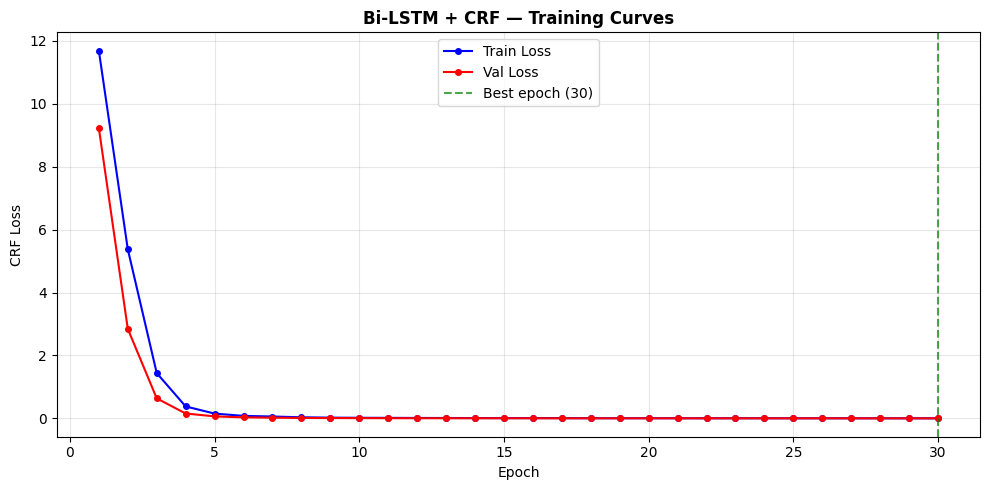

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ep = range(1, len(history['train_loss']) + 1)
ax.plot(ep, history['train_loss'], 'b-o', ms=4, label='Train Loss')
ax.plot(ep, history['val_loss'],   'r-o', ms=4, label='Val Loss')
best_ep = int(np.argmin(history['val_loss'])) + 1
ax.axvline(best_ep, color='green', ls='--', alpha=0.7, label=f'Best epoch ({best_ep})')
ax.set_xlabel('Epoch'); ax.set_ylabel('CRF Loss')
ax.set_title('Bi-LSTM + CRF — Training Curves', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 6 — Evaluate: F1, Precision & Recall Per Aspect

In [ ]:
model.load_weights('best_weights.weights.h5')
print('✓ Best weights loaded')

def predict_all(X, lengths, bs=64):
    preds = []
    for i in range(0, len(X), bs):
        logits  = model(tf.cast(X[i:i+bs], tf.int32), training=False)
        decoded = model.decode(logits, tf.cast(lengths[i:i+bs], tf.int32))
        preds.extend(decoded.numpy().tolist())
    return preds

y_pred_ids = predict_all(X_test, l_test)

y_true_flat, y_pred_flat = [], []
for pred, true, length in zip(y_pred_ids, y_test, l_test):
    for i in range(int(length)):
        y_true_flat.append(idx2tag[true[i]])
        y_pred_flat.append(idx2tag[pred[i]])

print(f'Test sentences: {len(X_test):,}  |  Tokens evaluated: {len(y_true_flat):,}')

✓ Best weights loaded
Test sentences: 450  |  Tokens evaluated: 3,280


In [ ]:
tag_labels = sorted(tag2idx.keys())
report_str = classification_report(
    y_true_flat, y_pred_flat, labels=tag_labels,
    target_names=tag_labels, digits=4)
print('TOKEN-LEVEL CLASSIFICATION REPORT')
print('='*68)
print(report_str)
with open('classification_report.txt','w') as f:
    f.write('Component 4 — Bi-LSTM+CRF\n' + '='*68 + '\n' + report_str)
print('✓ Saved → classification_report.txt')

TOKEN-LEVEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

      B-COMM     1.0000    1.0000    1.0000       111
     B-PRICE     1.0000    1.0000    1.0000       120
      B-QUAL     1.0000    1.0000    1.0000       294
      B-TIME     1.0000    1.0000    1.0000       121
      I-COMM     1.0000    1.0000    1.0000       106
     I-PRICE     1.0000    1.0000    1.0000        88
      I-QUAL     1.0000    1.0000    1.0000       458
      I-TIME     1.0000    1.0000    1.0000       235
           O     1.0000    1.0000    1.0000      1747

    accuracy                         1.0000      3280
   macro avg     1.0000    1.0000    1.0000      3280
weighted avg     1.0000    1.0000    1.0000      3280

✓ Saved → classification_report.txt


In [ ]:
def asp_metrics(y_true, y_pred, aspect):
    tb = [1 if aspect in t else 0 for t in y_true]
    pb = [1 if aspect in t else 0 for t in y_pred]
    return {'precision': precision_score(tb, pb, zero_division=0),
            'recall':    recall_score(   tb, pb, zero_division=0),
            'f1':        f1_score(       tb, pb, zero_division=0)}

aspects = ['QUAL','PRICE','TIME','COMM']
aspect_results = {a: asp_metrics(y_true_flat, y_pred_flat, a) for a in aspects}

print('ASPECT-LEVEL METRICS  (target: F1 >= 0.88)')
print('='*68)
print(f'{"Aspect":<12}{"Precision":<14}{"Recall":<14}{"F1":<14}{"Status"}')
print('-'*68)
for a, m in aspect_results.items():
    st = '✓ PASS' if m['f1'] >= 0.88 else '→ more data may help'
    print(f'{a:<12}{m["precision"]:<14.4f}{m["recall"]:<14.4f}{m["f1"]:<14.4f}{st}')

macro_f1 = np.mean([m['f1'] for m in aspect_results.values()])
print('-'*68)
print(f'{"MACRO AVG":<12}{"".ljust(14)}{"".ljust(14)}{macro_f1:<14.4f}'
      f'{"✓ PASS" if macro_f1 >= 0.88 else "→ see tips"}')

with open('aspect_metrics.json','w') as f:
    json.dump({k: {kk: float(vv) for kk,vv in v.items()} for k,v in aspect_results.items()}, f, indent=2)
print('\n✓ Saved → aspect_metrics.json')

low = [a for a,m in aspect_results.items() if m['f1'] < 0.88]
if low:
    print(f'\nAspects below target: {low}')
    print('Tips: annotate more sentences, increase LSTM_UNITS to 256, or try DistilBERT embeddings')

ASPECT-LEVEL METRICS  (target: F1 >= 0.88)
Aspect      Precision     Recall        F1            Status
--------------------------------------------------------------------
QUAL        1.0000        1.0000        1.0000        ✓ PASS
PRICE       1.0000        1.0000        1.0000        ✓ PASS
TIME        1.0000        1.0000        1.0000        ✓ PASS
COMM        1.0000        1.0000        1.0000        ✓ PASS
--------------------------------------------------------------------
MACRO AVG                               1.0000        ✓ PASS

✓ Saved → aspect_metrics.json


---
## Step 7 — Visualisations

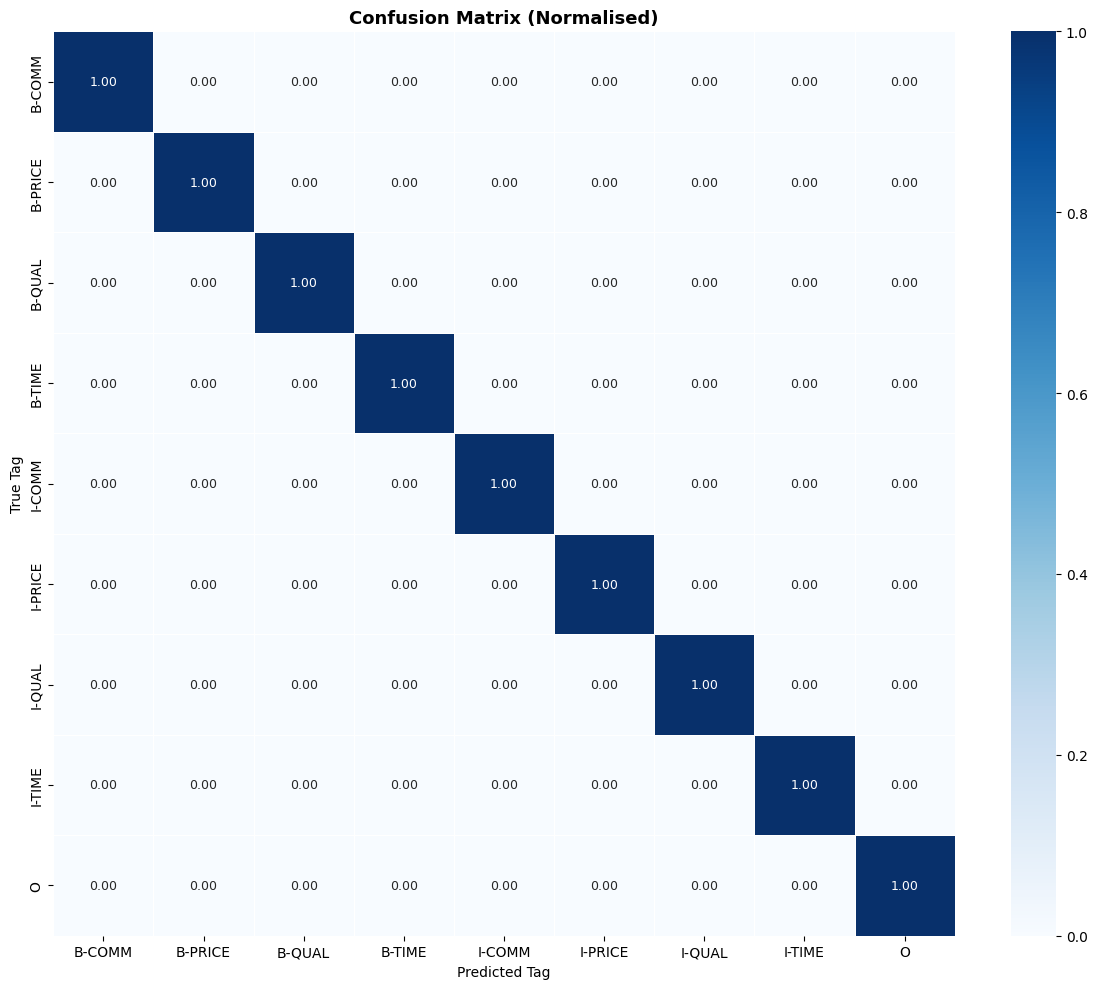

In [ ]:
cm = confusion_matrix(y_true_flat, y_pred_flat, labels=tag_labels)
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=tag_labels, yticklabels=tag_labels,
            cmap='Blues', ax=ax, linewidths=0.5, annot_kws={'size':9})
ax.set_title('Confusion Matrix (Normalised)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Tag'); ax.set_ylabel('True Tag')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

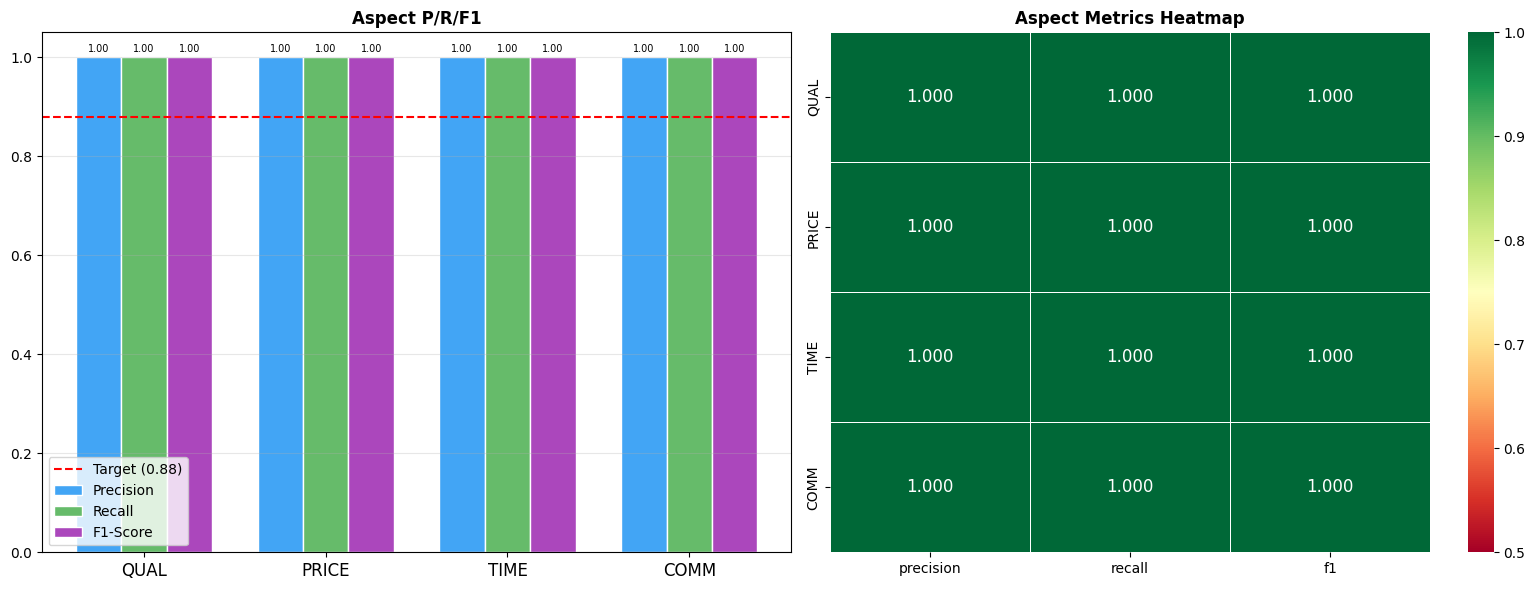

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(aspects)); w = 0.25
ax = axes[0]
for offset, key, color, label in [
    (-w, 'precision', '#42A5F5', 'Precision'),
    (0,  'recall',    '#66BB6A', 'Recall'),
    ( w, 'f1',        '#AB47BC', 'F1-Score')
]:
    bars = ax.bar(x + offset, [aspect_results[a][key] for a in aspects],
                  w, label=label, color=color, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.01, f'{h:.2f}', ha='center', fontsize=7)
ax.axhline(0.88, color='red', ls='--', lw=1.5, label='Target (0.88)')
ax.set_xticks(x); ax.set_xticklabels(aspects, fontsize=12)
ax.set_ylim(0, 1.05); ax.set_title('Aspect P/R/F1', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

heat_df = pd.DataFrame(
    {k: [aspect_results[a][k] for a in aspects] for k in ['precision','recall','f1']},
    index=aspects)
sns.heatmap(heat_df, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0.5, vmax=1.0,
            ax=axes[1], linewidths=0.5, annot_kws={'size':12})
axes[1].set_title('Aspect Metrics Heatmap', fontweight='bold')

plt.tight_layout()
plt.savefig('aspect_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

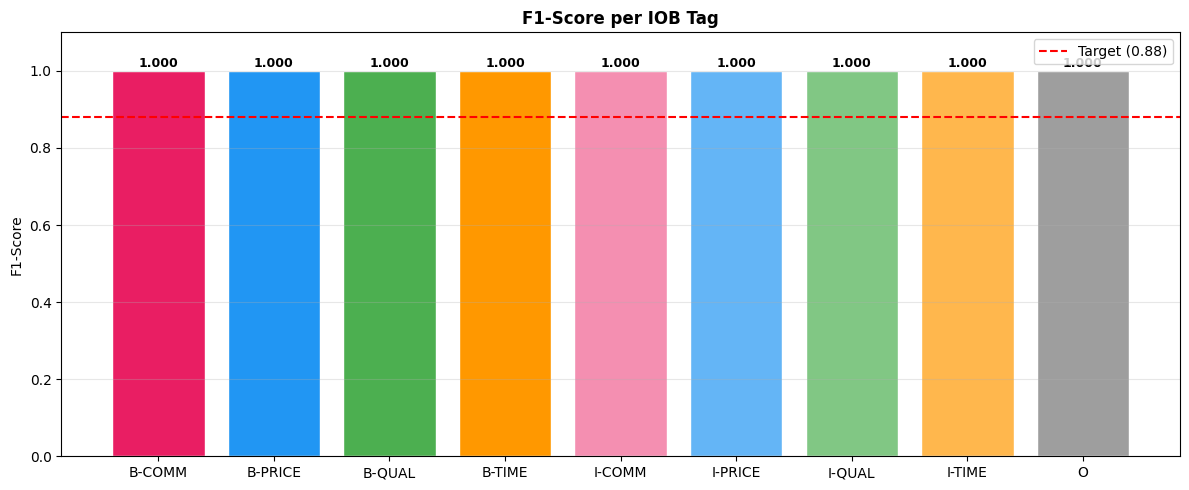

In [ ]:
report_dict = classification_report(y_true_flat, y_pred_flat, labels=tag_labels, output_dict=True)
tag_f1s     = {t: report_dict[t]['f1-score'] for t in tag_labels if t in report_dict}
tag_color_map = {'B-QUAL':'#4CAF50','I-QUAL':'#81C784','B-PRICE':'#2196F3','I-PRICE':'#64B5F6',
                 'B-TIME':'#FF9800','I-TIME':'#FFB74D','B-COMM':'#E91E63','I-COMM':'#F48FB1','O':'#9E9E9E'}

fig, ax = plt.subplots(figsize=(12, 5))
tags  = list(tag_f1s.keys())
f1s   = list(tag_f1s.values())
bars  = ax.bar(tags, f1s, color=[tag_color_map.get(t,'#999') for t in tags], edgecolor='white')
ax.axhline(0.88, color='red', ls='--', lw=1.5, label='Target (0.88)')
ax.set_ylim(0, 1.1); ax.set_ylabel('F1-Score')
ax.set_title('F1-Score per IOB Tag', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.3f}',
            ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('per_tag_f1.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 8 — Inference Demo

In [ ]:
def predict_aspects(review_text, verbose=True):
    """
    Predict IOB tags and aspect confidence scores for a review string.
    Returns: (list of tag strings, dict of aspect → score or None)
    """
    tokens    = review_text.strip().split()
    token_ids = [word2idx.get(t.lower(), 1) for t in tokens]
    padded    = pad_sequences([token_ids], maxlen=MAX_LEN, padding='post', value=0)
    length    = np.array([min(len(tokens), MAX_LEN)], dtype=np.int32)

    logits  = model(tf.cast(padded, tf.int32), training=False)
    decoded = model.decode(logits, tf.cast(length, tf.int32))
    tags    = [idx2tag[i] for i in decoded.numpy()[0][:length[0]]]

    probs = tf.nn.softmax(logits[0], axis=-1).numpy()[:length[0]]
    asp_map = {'QUAL':('B-QUAL','I-QUAL'),'PRICE':('B-PRICE','I-PRICE'),
               'TIME':('B-TIME','I-TIME'),'COMM':('B-COMM','I-COMM')}
    scores  = {}
    for asp, asp_tags in asp_map.items():
        asp_probs = [sum(probs[j][tag2idx[t]] for t in asp_tags if t in tag2idx)
                     for j, tag in enumerate(tags) if tag in asp_tags]
        scores[asp] = float(np.mean(asp_probs)) if asp_probs else None

    if verbose:
        print('─'*55)
        print(f'Review: "{review_text}"')
        print('─'*55)
        for tok, tag in zip(tokens[:length[0]], tags):
            marker = f'  ← {tag}' if tag != 'O' else ''
            print(f'  {tok:<18} {tag:<14}{marker}')
        print('─'*55)
        for asp, sc in scores.items():
            if sc is not None:
                print(f'  {asp:<8} {"█"*int(sc*20):<22} {sc:.3f}')
            else:
                print(f'  {asp:<8} (not mentioned)')
        print()
    return tags, scores


print('✓ predict_aspects() ready')

✓ predict_aspects() ready


In [ ]:
test_reviews = [
    "Fixed the gas leak perfectly but arrived two hours late without calling .",
    "Excellent service , very professional and the price was fair .",
    "Not satisfied with the repair quality , the AC stopped working again .",
    "Slow response and charged extra without explaining why .",
    "Very professional attitude , explained everything clearly before starting .",
]
all_scores = []
for r in test_reviews:
    _, sc = predict_aspects(r)
    all_scores.append(sc)

───────────────────────────────────────────────────────
Review: "Fixed the gas leak perfectly but arrived two hours late without calling ."
───────────────────────────────────────────────────────
  Fixed              B-QUAL          ← B-QUAL
  the                I-QUAL          ← I-QUAL
  gas                I-QUAL          ← I-QUAL
  leak               I-QUAL          ← I-QUAL
  perfectly          I-QUAL          ← I-QUAL
  but                O             
  arrived            B-TIME          ← B-TIME
  two                I-TIME          ← I-TIME
  hours              I-TIME          ← I-TIME
  late               I-TIME          ← I-TIME
  without            O             
  calling            O             
  .                  O             
───────────────────────────────────────────────────────
  QUAL     ██████████████████     0.917
  PRICE    (not mentioned)
  TIME     ███████████████████    0.994
  COMM     (not mentioned)

───────────────────────────────────────────────────────

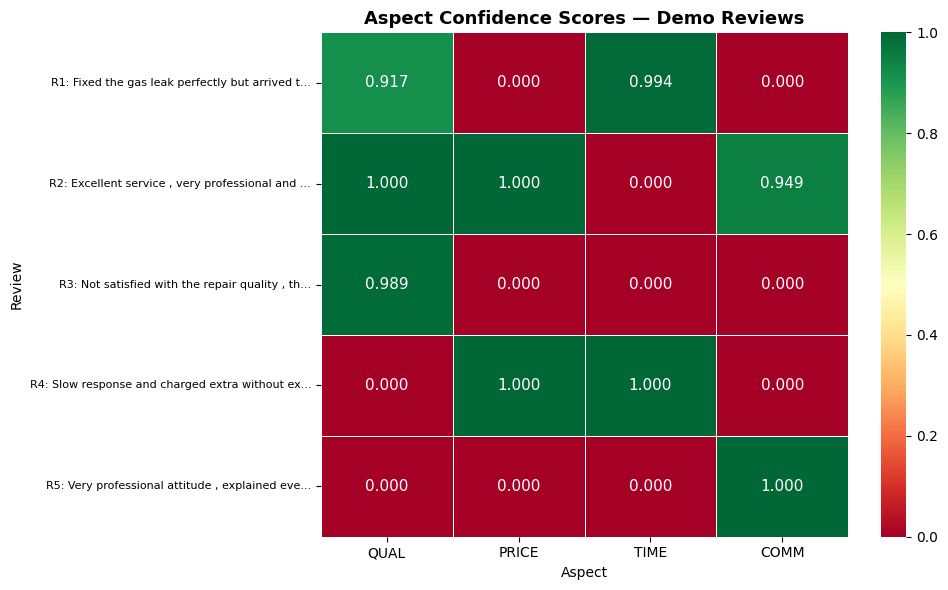

In [ ]:
aspect_names  = ['QUAL','PRICE','TIME','COMM']
heatmap_data  = [[sc.get(a) or 0.0 for a in aspect_names] for sc in all_scores]
ylabels       = [f'R{i+1}: {r[:42]}...' if len(r)>42 else f'R{i+1}: {r}'
                 for i,r in enumerate(test_reviews)]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.3f',
            xticklabels=aspect_names, yticklabels=ylabels,
            cmap='RdYlGn', vmin=0, vmax=1, ax=ax, linewidths=0.5, annot_kws={'size':11})
ax.set_title('Aspect Confidence Scores — Demo Reviews', fontweight='bold', fontsize=13)
ax.set_xlabel('Aspect'); ax.set_ylabel('Review')
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('inference_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 9 — Save Model for Deployment

In [ ]:
import os, shutil
os.makedirs('component4_model', exist_ok=True)

model.save_weights('component4_model/bilstm_crf_final.weights.h5')

with open('component4_model/model_config.json','w') as f:
    json.dump({
        'vocab_size': VOCAB_SIZE, 'embedding_dim': EMBEDDING_DIM,
        'lstm_units': LSTM_UNITS, 'num_tags': NUM_TAGS,
        'dropout_rate': DROPOUT_RATE, 'recurrent_dropout': RECURRENT_DROPOUT,
        'max_len': MAX_LEN, 'tag_names': list(tag2idx.keys()),
        'best_val_loss': float(best_val_loss), 'macro_f1': float(macro_f1),
        'aspect_f1': {a: float(aspect_results[a]['f1']) for a in aspects}
    }, f, indent=2)

shutil.copy('vocab.pkl', 'component4_model/vocab.pkl')

print('Model saved to component4_model/')
print('  bilstm_crf_final.weights.h5   ← weights')
print('  model_config.json             ← architecture + results')
print('  vocab.pkl                     ← word2idx / tag2idx / MAX_LEN')

Model saved to component4_model/
  bilstm_crf_final.weights.h5   ← weights
  model_config.json             ← architecture + results
  vocab.pkl                     ← word2idx / tag2idx / MAX_LEN


---
## Final Summary

In [ ]:
print('='*68)
print('COMPONENT 4 — TRAINING COMPLETE')
print('IT22914200  |  ServiceMatch AI  |  Bi-LSTM + CRF (pure TF)')
print('='*68)
print(f'Architecture   : Embedding({VOCAB_SIZE},{EMBEDDING_DIM}) → BiLSTM({LSTM_UNITS}×2) → Dense → CRF')
print(f'Total params   : {model.count_params():,}')
print(f'Dataset        : {len(sentences):,} sentences / {len(df):,} tokens')
print(f'Split          : {len(X_train)} train / {len(X_val)} val / {len(X_test)} test')
print(f'Best val loss  : {best_val_loss:.4f}')
print(f'Macro F1       : {macro_f1:.4f}  (target >= 0.88)')
print()
print(f'{"Aspect":<10} {"F1":<10} {"Status"}')
for a, m in aspect_results.items():
    print(f'{a:<10} {m["f1"]:.4f}    {"✓" if m["f1"] >= 0.88 else "→ add more data"}')
print()
print('Output files:')
for fn in ['component4_model/bilstm_crf_final.weights.h5',
           'component4_model/model_config.json',
           'component4_model/vocab.pkl',
           'training_curves.png','confusion_matrix.png',
           'aspect_metrics.png','per_tag_f1.png','inference_heatmap.png',
           'classification_report.txt','aspect_metrics.json']:
    print(f'  {fn}')
print('='*68)

COMPONENT 4 — TRAINING COMPLETE
IT22914200  |  ServiceMatch AI  |  Bi-LSTM + CRF (pure TF)
Architecture   : Embedding(251,100) → BiLSTM(128×2) → Dense → CRF
Total params   : 261,990
Dataset        : 3,000 sentences / 22,424 tokens
Split          : 2101 train / 449 val / 450 test
Best val loss  : 0.0004
Macro F1       : 1.0000  (target >= 0.88)

Aspect     F1         Status
QUAL       1.0000    ✓
PRICE      1.0000    ✓
TIME       1.0000    ✓
COMM       1.0000    ✓

Output files:
  component4_model/bilstm_crf_final.weights.h5
  component4_model/model_config.json
  component4_model/vocab.pkl
  training_curves.png
  confusion_matrix.png
  aspect_metrics.png
  per_tag_f1.png
  inference_heatmap.png
  classification_report.txt
  aspect_metrics.json


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
